In [17]:
# === Notebook path and directory configuration ===
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
if CWD.name == "diagnostic":
    DIAGNOSTIC_DIR = CWD
elif (CWD / "diagnostic").is_dir():
    DIAGNOSTIC_DIR = CWD / "diagnostic"
else:
    DIAGNOSTIC_DIR = next((p for p in [CWD, *CWD.parents] if p.name == "diagnostic"), CWD.parent)

if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

model_outpath = Path("/compyfs/zhan391/v3_dart_cda_scratch")
dart_outpath = model_outpath

DIAG_OUT_DIR = Path("/compyfs/www/zhan391/e3sm_dart/diag_out")
DIAG_DATA_DIR = DIAG_OUT_DIR / "data"
DIAG_FIGURE_DIR = DIAG_OUT_DIR / "figure"

DIAG_DATA_DIR.mkdir(parents=True, exist_ok=True)
DIAG_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

import os, re
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from typing import Dict, List, Optional, Tuple

from util.dart_obs_diag import (
    DartObsDiagReader
)

In [18]:
from configs.analysis_da_experiment_config import extract_exp_info

# User setup: edit this dictionary when experiment names, run sets, periods,
# ensemble sizes, aliases, or available obs diagnostics change.
USER_EXPERIMENTS = {
    "CTRL": {
        "nens": 1,
        "key": "ctrl",
        "da_run": None,
        "fc_run": {"compset": "F20TR", "name": "CTRL", "period": "201201-201212"},
        "wc_run": {"compset": "WCYCL20TR", "name": "CTRL", "period": "201201-201212"},
    },
    "CTRL10-S0": {
        "nens": 10,
        "key": "dart_en10",
        "da_run": {
            "compset": "F20TR", "name": "CTRLEN10", "period": "201112-201112",
            "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
        },
        "fc_run": {"compset": "F20TR", "name": "CTRLEN10_15day", "period": "201201-201202"},
        "wc_run": {"compset": "WCYCL20TR", "name": "CTRLEN10_15day", "period": "201201-201202"},
    },
    "CAPT10-S0": {
        "nens": 10,
        "key": "dart_en10",
        "da_run": None,
        "fc_run": {"compset": "F20TR", "name": "CAPTEN10_15day", "period": "201201-201202"},
        "wc_run": {"compset": "WCYCL20TR", "name": "CAPTEN10_15day", "period": "201201-201202"},
    },
    "DART10-S0": {
        "nens": 10,
        "key": "dart_en10",
        "da_run": {
            "compset": "F20TR", "name": "DARTEN10", "period": "201112-201112",
            "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
        },
        "fc_run": None,
        "wc_run": None,
    },
    "DART20-S0": {
        "nens": 20,
        "key": "dart_en20",
        "da_run": {
            "compset": "F20TR", "name": "DARTEN20", "period": "201112-201112",
            "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
        },
        "fc_run": {"compset": "F20TR", "name": "DARTEN20_15day", "period": "201201-201202"},
        "wc_run": {"compset": "WCYCL20TR", "name": "DARTEN20_15day", "period": "201201-201202"},
    },
    "DART40-S0": {
        "nens": 40,
        "key": "dart_en40",
        "da_run": {
            "compset": "F20TR", "name": "DARTEN40", "period": "201112-201112",
            "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
        },
        "fc_run": {"compset": "F20TR", "name": "DARTEN40_15day", "period": "201201-201202"},
        "wc_run": {"compset": "WCYCL20TR", "name": "DARTEN40_15day", "period": "201201-201202"},
    },
    "DART40INF0p6-S0": {
        "nens": 40,
        "key": "dart_en40",
        "da_run": {
            "compset": "F20TR", "name": "DARTEN40_INF0p6", "alias": "DARTEN40", "period": "201112-201112",
            "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
        },
        "fc_run": None,
        "wc_run": None,
    },
    "CTRL10-S1": {
        "nens": 10,
        "key": "ctrl_en10",
        "da_run": None,
        "fc_run": {"compset": "F20TR", "name": "CTRLEN10s1_15day", "period": "201206-201207"},
        "wc_run": {"compset": "WCYCL20TR", "name": "CTRLEN10s1_15day", "period": "201206-201207"},
    },
    "CAPT10-S1": {
        "nens": 10,
        "key": "capt_en10",
        "da_run": None,
        "fc_run": {"compset": "F20TR", "name": "CAPTEN10S1_15day", "period": "201206-201207"},
        "wc_run": {"compset": "WCYCL20TR", "name": "CAPTEN10S1_15day", "period": "201206-201207"},
    },
    "DART40-S1": {
        "nens": 40,
        "key": "dart_en40",
        "da_run": {
            "compset": "F20TR", "name": "DARTEN40S1", "period": "201205-201205",
            "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
        },
        "fc_run": {"compset": "F20TR", "name": "DARTEN40S1_15day", "period": "201206-201207"},
        "wc_run": {"compset": "WCYCL20TR", "name": "DARTEN40S1_15day", "period": "201206-201207"},
    },
}

# Optional layer for temporary add/update/remove changes. Set an experiment to None
# here to remove it without touching USER_EXPERIMENTS.
USER_EXPERIMENT_OVERRIDES = {}

In [19]:
class ObsLocation2DPlotter:
    """
    Draw 2D scatter maps of observation locations, grouped by bins, for one or more models.
    No GeoCAT required.
    """

    DEFAULT_COLORS = {
        'blue':   '#377eb8', 'orange': '#ff7f00', 'green':  '#4daf4a',
        'pink':   '#f781bf', 'brown':  '#a65628', 'purple': '#984ea3',
        'gray':   '#999999', 'red':    '#e41a1c', 'yellow': '#dede00'
    }

    def __init__(self,
                 projection: ccrs.Projection = ccrs.PlateCarree(),
                 cmap_dict: Optional[Dict[str, str]] = None,
                 font_base: float = 14.0):
        self.projection = projection
        self.cmap = (cmap_dict or self.DEFAULT_COLORS).copy()
        self.font_base = font_base

    @staticmethod
    def define_region(regnam: str = 'global') -> Tuple[Tuple[float, float], Tuple[float, float]]:
        """
        Return latitude and longitude bounds for a named region.

        Parameters
        ----------
        regnam : str
            Region name (e.g., 'global', 'Atlantic', 'CONUS', 'Antarctic', 'PolarN', 'Greenland').

        Returns
        -------
        tuple of tuple
            ((lat_min, lat_max), (lon_min, lon_max))
        """
        reg_dict = {
            'global':    [(-90, 90), (-180, 180)],
            'Atlantic':  [(10, 90), (-100, 10)],
            'CONUS':     [(25, 50), (235, 295)],
            'Antarctic': [(-90, -50), (-180, 180)],
            'PolarN':    [(50, 90), (-180, 180)],
            'Greenland': [(60, 85), (-75, -10)],
        }

        if regnam not in reg_dict:
            raise ValueError(f"Unknown region name '{regnam}'. Available: {list(reg_dict.keys())}")
        return reg_dict[regnam]
    
    # -------------------------- helpers --------------------------

    @staticmethod
    def _scaled_font(fgw: float, fgh: float) -> float:
        # Simple heuristic that keeps sizes reasonable across aspect ratios
        aspect = fgw / max(fgh, 1e-6)
        return 12.0 * np.sqrt(aspect)

    @staticmethod
    def _parse_extent(var_dict: Dict) -> List[float]:
        """
        Parse [lon_min, lon_max, lat_min, lat_max] from var_dict['region'].
        Falls back to global extent if missing/malformed.
        Wrap rule: if both lon bounds are >=0 and max >=180, subtract 180.
        """
        default_extent = [-180.0, 180.0, -90.0, 90.0]
        try:
            region_str = str(var_dict.get('region', ''))
            toks = region_str.split()
            extent = [float(tok) for tok in toks[:4]]
            if len(extent) != 4:
                return default_extent
            if extent[0] >= 0 and extent[1] >= 180:
                extent[0] -= 180.0
                extent[1] -= 180.0
            # sanity
            if extent[0] >= extent[1] or extent[2] >= extent[3]:
                return default_extent
            return extent
        except Exception:
            return default_extent

    def _setup_basemap(self, ax, extent: List[float]) -> None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, color='silver', zorder=0)
        ax.add_feature(cfeature.LAKES, facecolor='white', edgecolor='none', zorder=0)
        ax.coastlines(linewidth=0.6, color="black", zorder=1)

    def _apply_gridlines(self, ax, extent: List[float], fontz: float) -> None:
        """Cartopy-only longitude/latitude gridlines with degree labels."""
        gl = ax.gridlines(
            draw_labels=True, crs=ccrs.PlateCarree(),
            linewidth=0.5, linestyle='--', alpha=0.5
        )
        # Major tick spacing
        x_ticks = np.arange(extent[0], extent[1] + 1e-6, 60)
        y_ticks = np.arange(extent[2], extent[3] + 1e-6, 30)
        gl.xlocator = mticker.FixedLocator(x_ticks)
        gl.ylocator = mticker.FixedLocator(y_ticks)
        gl.xformatter = LongitudeFormatter(number_format='.0f')
        gl.yformatter = LatitudeFormatter(number_format='.0f')
        # Tolerate Cartopy version differences
        for attr, val in [('top_labels', False), ('right_labels', False)]:
            if hasattr(gl, attr):
                setattr(gl, attr, val)
        if hasattr(gl, 'xlabel_style'):
            gl.xlabel_style = {'size': fontz}
        if hasattr(gl, 'ylabel_style'):
            gl.ylabel_style = {'size': fontz}

    @staticmethod
    def _concat(seq) -> np.ndarray:
        """Concatenate list of arrays or scalars robustly into one 1D array."""
        if len(seq) == 0:
            return np.array([])
        if isinstance(seq[0], (list, tuple, np.ndarray)):
            if len(seq) == 0:
                return np.array([])
            return np.concatenate([np.asarray(x).ravel() for x in seq]) if len(seq) else np.array([])
        return np.asarray(seq).ravel()

    def _concat_and_wrap_lons(self, lons_seq) -> np.ndarray:
        """Concatenate lons and wrap >180 → lon-360 (to [-180,180])."""
        arr = self._concat(lons_seq)
        if arr.size == 0:
            return arr
        arr_wrapped = np.where(arr > 180.0, arr - 360.0, arr)
        return arr_wrapped

    # -------------------------- public API --------------------------
    def plot(self,
             date: str,
             var: str,
             var_dict: Dict,
             data_dict: Dict[str, Dict[str, Dict[str, List[np.ndarray]]]],
             fig_path: str,
             fgw: float = 35,
             fgh: float = 25,
             hs: float = 0.5,
             ws: float = 0.5,
             dpi: int = 300,
             fontz: float = 12, 
             crop_white: bool = True,
             save_png: bool = True, 
             marker_size_base: float = 20.0,
             marker_alpha: float = 0.5) -> str:
        """
        Render the multi-panel observation-location map and save to PDF.

        date, var, var_dict, data_dict : same semantics as your original function.
        fig_path : directory to write the PDF into.
        """
        extent = self._parse_extent(var_dict)
        ncols = len(data_dict)

        fig, axes = plt.subplots(
            1, ncols, figsize=(fgw, fgh),
            subplot_kw={'projection': self.projection}
        )
        if ncols == 1:
            axes = [axes]

        # Font scaling (keeps relative sizes similar as aspect changes)
        if fontz is None:
            fontz = self._scaled_font(fgw, fgh)

        # Precompute a repeating color list (handles > len(colors))
        color_keys = list(self.cmap.keys())
        if not color_keys:
            raise ValueError("cmap_dict/DEFAULT_COLORS is empty.")
        # Build a long enough color list once
        max_bins = max(len(data_dict[m]) for m in data_dict) if ncols else 0
        color_cycle = (color_keys * ((max_bins // len(color_keys)) + 1))[:max_bins]

        for i, model in enumerate(data_dict):
            ax = axes[i]
            self._setup_basemap(ax, extent)
            self._apply_gridlines(ax, extent, fontz)

            # Deterministic bin order
            bins = sorted(list(data_dict[model].keys()), key=lambda x: str(x).upper())

            # Size ramp scaled by requested base
            if len(bins) > 1:
                sizes = np.linspace(0.8, 1.2, len(bins)) * marker_size_base
            else:
                sizes = np.array([marker_size_base])

            total_points = 0
            bin_coords = {}

            # Collect/normalize lon/lat
            for bin_key in bins:
                lons_raw = data_dict[model][bin_key].get('lon', [])
                lats_raw = data_dict[model][bin_key].get('lat', [])
                lons = self._concat_and_wrap_lons(lons_raw)
                lats = self._concat(lats_raw)
                # Align lengths if needed and drop NaNs
                if lons.size != lats.size:
                    n = min(lons.size, lats.size)
                    lons, lats = lons[:n], lats[:n]
                mask = np.isfinite(lons) & np.isfinite(lats)
                lons, lats = lons[mask], lats[mask]

                label = str(bin_key).upper()
                bin_coords[label] = {'lon': lons, 'lat': lats}
                total_points += lons.size

            total_points = max(total_points, 1)  # avoid zero division

            # Scatter each bin
            for j, label in enumerate(bin_coords):
                ratio = 100.0 * bin_coords[label]['lon'].size / total_points
                ax.scatter(
                    bin_coords[label]['lon'], bin_coords[label]['lat'],
                    label=f"{label} ({ratio:.1f}%)",
                    s=sizes[j],
                    color=self.cmap[color_cycle[j]],
                    alpha=marker_alpha,
                    linewidths=0.0,
                    transform=ccrs.PlateCarree(),
                    zorder=2,
                )

            # Legend
            nnlab = 3
            bbox_anchor = (0.01, -0.20) if len(bin_coords) <= nnlab else (-0.05, -0.30)
            ax.legend(
                bbox_to_anchor=bbox_anchor, ncol=nnlab, fontsize=fontz * 0.95,
                loc='lower left', markerscale=3.0, scatterpoints=1,
                columnspacing=1.0, frameon=False
            )
            
            panel_label = f"({chr(97 + i)}) {model.capitalize()}"  # 97 = 'a'
            ax.set_title(
                panel_label, 
                loc='left', 
                fontsize=fontz * 1.0, 
                pad=10,
            )
            
            ax.tick_params(labelsize=fontz * 0.95, length=6)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(top=False, right=False)

        plt.subplots_adjust(hspace=hs, wspace=ws)

        # --- Create output directory ---
        os.makedirs(fig_path, exist_ok=True)
        pdf_filename = os.path.join(fig_path, f"fig_2d_obs_{var}_{date}.pdf")

        # --- Force proper draw and white background ---
        fig.canvas.draw()  # ensures Cartopy renders before save
        fig.patch.set_facecolor("white")
        for ax in np.atleast_1d(axes):
            ax.patch.set_facecolor("white")

        # --- Save tightly cropped PDF ---
        fig.savefig(
            pdf_filename,
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.05,
            facecolor="white"
        )
        
        # --- Also save as PNG ---
        if save_png: 
            png_filename = pdf_filename.replace(".pdf", ".png")
            fig.savefig(
                png_filename,
                dpi=600,  # you can increase this (e.g., 300–600) for high-quality PNG
                bbox_inches="tight",
                pad_inches=0.05,
                facecolor="white"
            )
        # --- Display figure interactively before closing ---
        plt.show()

        # --- Clean up memory after display ---
        plt.close(fig)

        return pdf_filename

[INFO] Writing obs-distribution figures to: /compyfs/www/zhan391/e3sm_dart/diag_out/figure/analysis_da/obs_distribution
[RESOLVE] obs_seq (swap): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_seq/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_seq_final.2011-12-03-*.nc
[OBS-SEQ] files: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_seq/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_seq_final.2011-12-03-*.nc
[READ obs_seq] /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_seq/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_seq_final.2011-12-03-*.nc
[INFO] Extracted 22 obs types from file:
      1: GPSRO_REFRACTIVITY                       (code=4)
      2: RADIOSONDE_U_WIND_COMPONENT              (code=51)
      3: RA

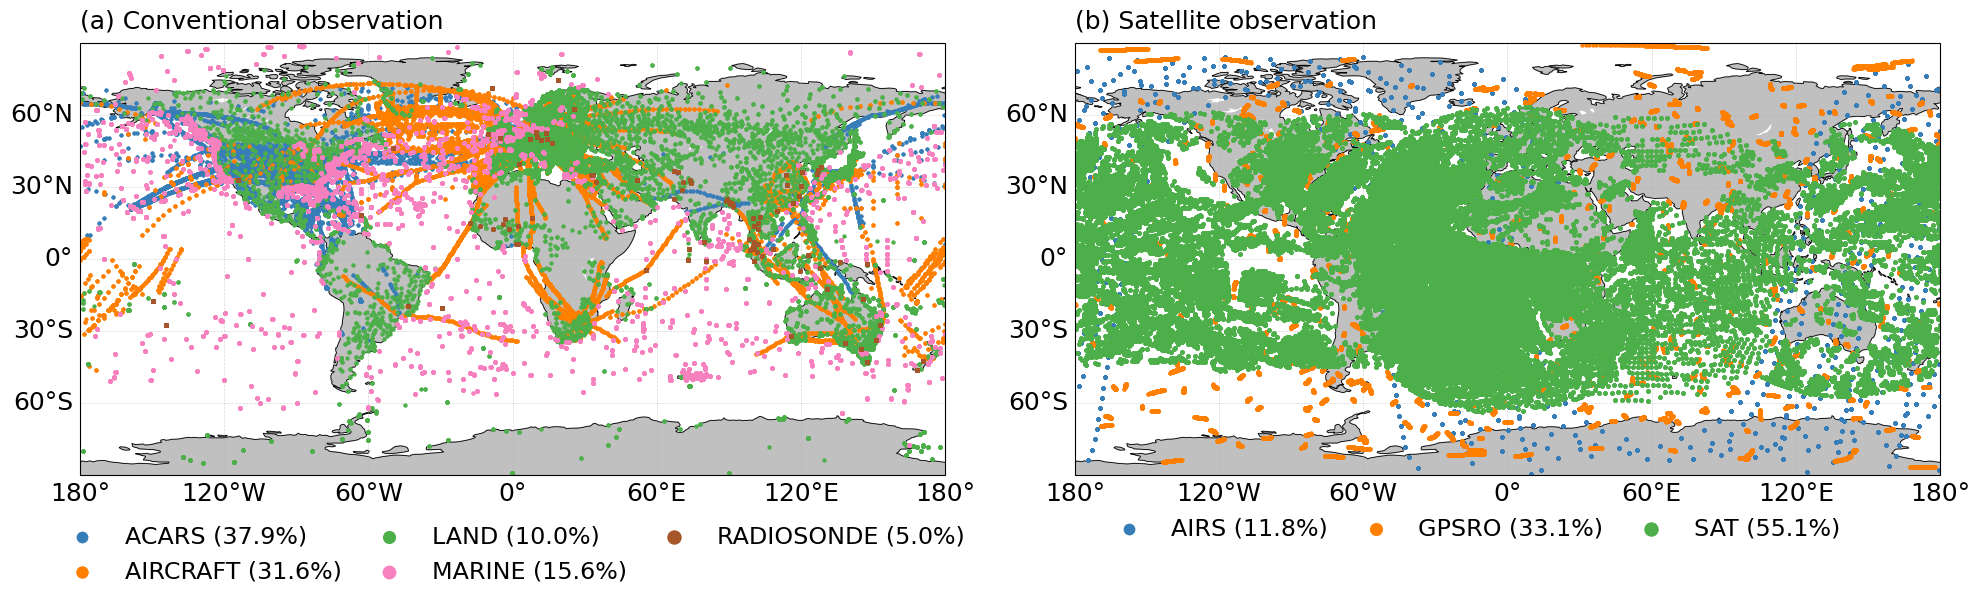

Saved: /compyfs/www/zhan391/e3sm_dart/diag_out/figure/analysis_da/obs_distribution/fig_2d_obs_all_2011-12-03.pdf


In [20]:
# --- Inputs ---
# Source roots: model_outpath, dart_outpath (configured above)
fig_path   = str(DIAG_FIGURE_DIR / "analysis_da" / "obs_distribution")
exp_list   = ["DART20-S0"]          # loop-able
per_list   = ["2011-12-03"]         # single-date stamps for obs_seq
regnam_key = "GB"                   # GB, NH, SH, TP, NA
var        = "all"

fgw=24                # figure size
fgh=12                # figure size
hs=0.4                # row space between panels
ws=0.15               # column space between panels
marker_size_base=10   # base marker size per-bin (auto-scales slightly)
marker_alpha=1.0      # point transparency
dpi=200               # image resolution
fontz=18              #
crop_white=True

print(f"[INFO] Writing obs-distribution figures to: {fig_path}")

# observation types to KEEP (set to None or "all" to keep everything)
# Examples:
# obs_filter = "RADIOSONDE_TEMPERATURE"
# obs_filter = ["RADIOSONDE_U_WIND_COMPONENT", "RADIOSONDE_V_WIND_COMPONENT"]
# obs_filter = "group:Conventional"
# obs_filter = r"regex:^RADIOSONDE_"
# obs_filter = [3, 17]  # by numeric DART codes
obs_filter = None

# Region dictionary with OPTIONAL vertical bounds (z_lo, z_hi)
# NOTE: 120000 = 120 km (typical). You had 1200000 = 1200 km—keep only if intended.
region_dict = {
    'GB': {"name": "Global",              "region": [(-90, 90), (0, 360), (0, 120000)]},
    'NH': {"name": "Northern Hemisphere", "region": [(20, 90),  (0, 360), (0, 120000)]},
    'SH': {"name": "Southern Hemisphere", "region": [(-90, 20), (0, 360), (0, 120000)]},
    'TP': {"name": "Tropics",             "region": [(-20, 20), (0, 360), (0, 120000)]},
    'NA': {"name": "North America",       "region": [(25, 55),  (235, 295), (0, 120000)]},
}

# Optional: you can also just set var_dict_entry = None to use class defaults
var_dict_entry = {
    "ObsTypeString": "all",            # informational for labeling only
    "CopyString": "observation",       # or "NCEP BUFR observation", etc.
    "QCString": "DART quality control",
    "verbose": False,
    # no "region" here -> class will compute it from region_dict + regnam_key
}

# Build experiments
all_exps: Dict[str, dict] = extract_exp_info(
    str(model_outpath),
    experiments=USER_EXPERIMENTS,
    experiment_overrides=USER_EXPERIMENT_OVERRIDES,
)

# Reader (obs_seq + obs_diag templates; we use obs_seq here)
reader = DartObsDiagReader(config={
    "data_path": str(dart_outpath),
    "path_template": "{data_path}/{run_id}/archive/{group_key}/dart_diagnostics/{diag_set}",
    "file_templates": {
        "obs_diag": "{run_id}.dart.e.eam_{diag_set}_output.{period}.nc",
        "obs_seq":  "{name}.dart.e.eam_{diag_set}_final.{period}-*.nc",
    },
    "region_dict": region_dict,
})

# --- Loop over experiments, using ONLY runs['da'] ---
for exp_name, date_stamp in zip(exp_list, per_list):
    if exp_name not in all_exps:
        print(f"[WARN] Experiment '{exp_name}' not found in extracted metadata.")
        continue

    exp_entry = all_exps[exp_name]
    da_run    = exp_entry["runs"].get("da")
    group_key = exp_entry.get("group_key")

    if da_run is None:
        print(f"[WARN] No DA run for '{exp_name}'. Skipping.")
        continue
    if not group_key:
        print(f"[WARN] group_key missing for '{exp_name}'. Using exp_name as fallback.")
        group_key = exp_name

    # Ensure 'name' exists for the filename template
    if not da_run.get("name"):
        da_run = {**da_run, "name": exp_name}

    data_dict = reader.make_obs_seq_datadict(
        exp_name=exp_name,
        da_run_subrun=da_run,
        group_key=group_key,
        date_stamp=date_stamp,
        reg_key=regnam_key,
        var=var,                          # placeholder for obs_seq, safe to keep
        var_dict_entry=var_dict_entry,    # or None to use defaults
        obs_filter=obs_filter,            # keep these obs types; None/"all" keeps all
    )

    if not data_dict:
        print(f"[INFO] No data returned for {exp_name} {date_stamp} (region={regnam_key}).")
        continue

    # Quick summary: count observations per group/subtype
    print(f"[OK] {exp_name} {date_stamp} | groups:", list(data_dict.keys()))
    for grp, sub in data_dict.items():
        for subtyp, dd in sub.items():
            npts = sum(arr.size for arr in dd["obs"])  # lists of arrays
            print(f"  - {grp:13s} / {subtyp:12s}: {npts:7d} obs")
            
    # === Plot ===
    lat_lo, lat_hi, lon_lo, lon_hi, z_lo, z_hi = reader._unpack_region(reader.region_dict[regnam_key]["region"])
    plot_var_dict = {
        # z bounds are fine to include; the plotter only reads the first 4 numbers
        "region": f"{lon_lo} {lon_hi} {lat_lo} {lat_hi} {z_lo if z_lo is not None else 0} {z_hi if z_hi is not None else 120000}"
    }
    # 2) Choose what to plot.
    #    One panel with just Conventional:
    #plot_data = {"Conventional": data_dict.get("Conventional", {})}
    #    Or multiple panels side-by-side (Conventional & Satellite):
    plot_data = {
         "Conventional Observation": data_dict.get("Conventional", {}),
         "Satellite Observation":    data_dict.get("Satellite", {}),
    }
    # 3) Make the figure
    plotter = ObsLocation2DPlotter(
        projection=ccrs.PlateCarree(),
        # optional: override colors with a dict of {name: hex}
        # cmap_dict={"blue":"#377eb8","orange":"#ff7f00", ...}
    )
    out_pdf = plotter.plot(
        date=date_stamp,
        var=var,
        var_dict=plot_var_dict,
        data_dict=plot_data,
        fig_path=fig_path,          # output directory will be created if missing
        fgw=fgw, fgh=fgh,              # figure size
        hs=hs, ws=ws,
        fontz = fontz, 
        marker_size_base=marker_size_base,        # base marker size per-bin (auto-scales slightly)
        marker_alpha=marker_alpha,           # point transparency
        dpi=dpi,                    # image resolution
        crop_white=crop_white
    )
    plt.show()
    print("Saved:", out_pdf)
    